In [2]:
# Testing the kernel

print("hello world")

hello world


In [2]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Add src to path to import our modules
sys.path.append(os.path.abspath("../src"))

import config
from dataset import HubbleDataProcessor, HubbleDataset
from model import ZeroTrustAutoencoder

print("Environment Ready.")


Environment Ready.


🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_training_data.json...
✅ Filtered down to 100 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.
 Simulating Training to capture Loss Curve...


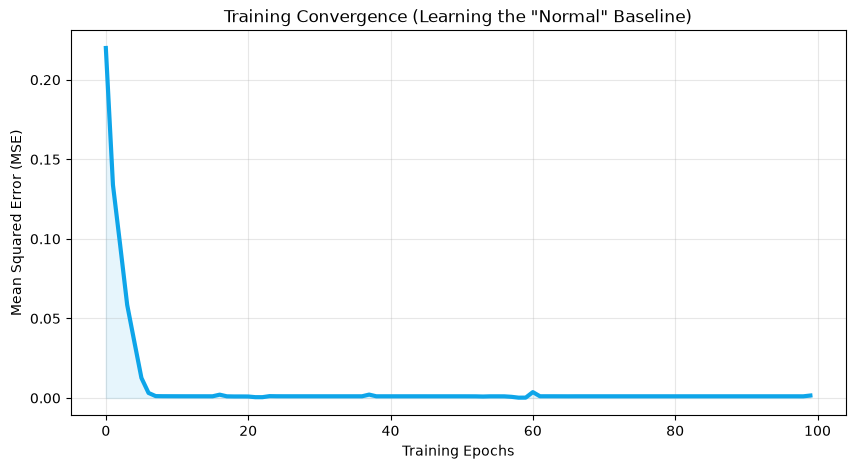

In [3]:

processor = HubbleDataProcessor(config.TRAIN_DATA_PATH)
processor.load_and_filter()
processor.engineer_features()
df_train = processor.get_dataframe()

input_dim = df_train.shape[1]
train_loader = DataLoader(HubbleDataset(df_train), batch_size=8, shuffle=True)


live_model = ZeroTrustAutoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(live_model.parameters(), lr=0.01)

epoch_history = []
loss_history = []

print(" Simulating Training to capture Loss Curve...")
for epoch in range(100):
    total_loss = 0
    for batch_features, _ in train_loader:
        reconstructed = live_model(batch_features)
        loss = criterion(reconstructed, batch_features)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    epoch_history.append(epoch)
    loss_history.append(avg_loss)


plt.figure(figsize=(10, 5))
plt.plot(epoch_history, loss_history, color='#0ea5e9', linewidth=3)
plt.title('Training Convergence (Learning the "Normal" Baseline)')
plt.xlabel('Training Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, alpha=0.3)
plt.fill_between(epoch_history, loss_history, color='#0ea5e9', alpha=0.1)
plt.show()


🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_attack_data.json...
✅ Filtered down to 26 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.


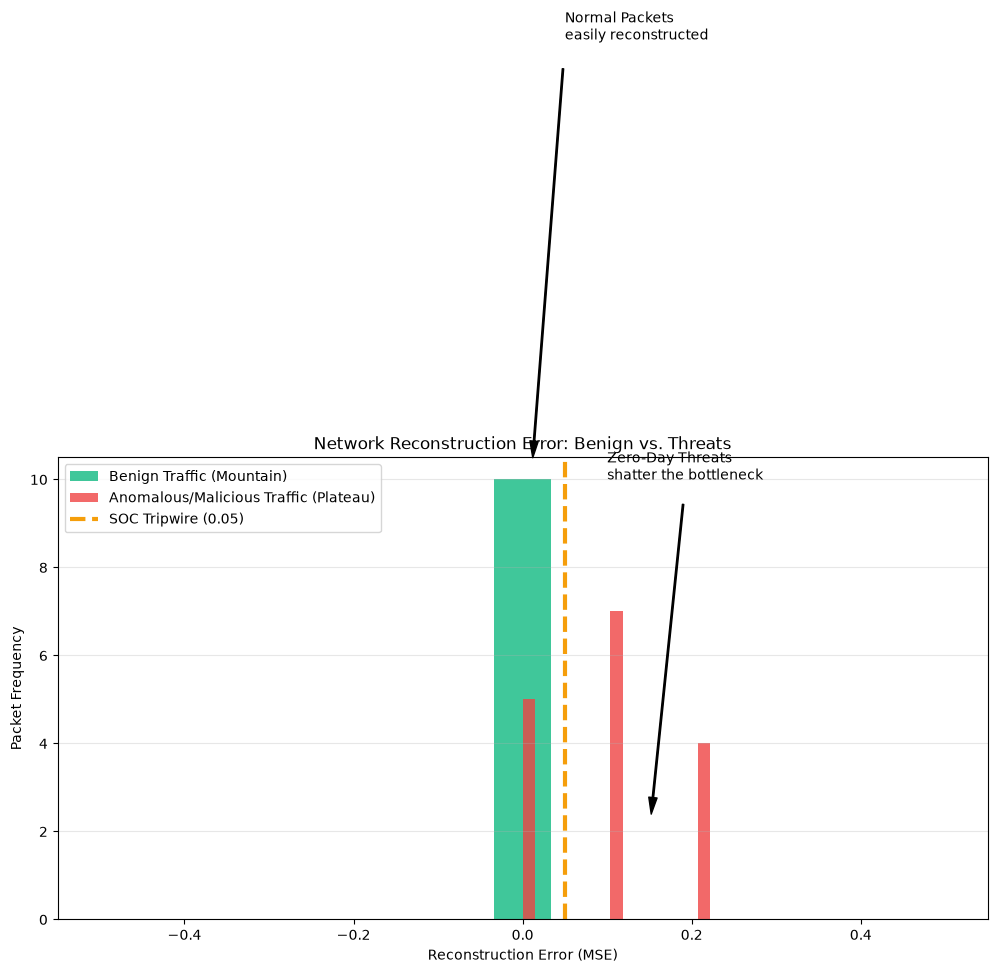

In [6]:
### this is not done yet please ignore



test_processor = HubbleDataProcessor(config.TEST_DATA_PATH)
test_processor.load_and_filter()
test_processor.engineer_features()
df_test = test_processor.get_dataframe()
raw_events = test_processor.raw_data


normal_mses = []
anomaly_mses = []


live_model.eval()

for i in range(len(df_test)):
    row_tensor = torch.FloatTensor(df_test.iloc[i].values)
    context = raw_events[i]
    
    with torch.no_grad():
        reconstructed = live_model(row_tensor)
        mse_loss = criterion(reconstructed, row_tensor).item()
        
    # Heuristic for the plot: Separate known attacks from normal traffic
    if context['method'] in ['POST', 'DELETE'] or df_test.iloc[i]['is_valid_path'] == 0.0:
        anomaly_mses.append(mse_loss)
    else:
        normal_mses.append(mse_loss)

# 3. Plot Diagram 2
plt.figure(figsize=(12, 6))

# The "Tall Mountain Near Zero"
plt.hist(normal_mses, bins=15, alpha=0.8, color='#10b981', label='Benign Traffic (Mountain)')

# The "Far Plateaued Hill"
plt.hist(anomaly_mses, bins=15, alpha=0.8, color='#ef4444', label='Anomalous/Malicious Traffic (Plateau)')

# The Tripwire
plt.axvline(x=0.05, color='#f59e0b', linestyle='--', linewidth=3, label='SOC Tripwire (0.05)')

plt.title('Network Reconstruction Error: Benign vs. Threats')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Packet Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.annotate('Normal Packets\neasily reconstructed', xy=(0.01, 10), xytext=(0.05, 20),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.annotate('Zero-Day Threats\nshatter the bottleneck', xy=(0.15, 2), xytext=(0.10, 10),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.show()


🚀 Running Hyperparameter Grid Search (Learning Rates)...


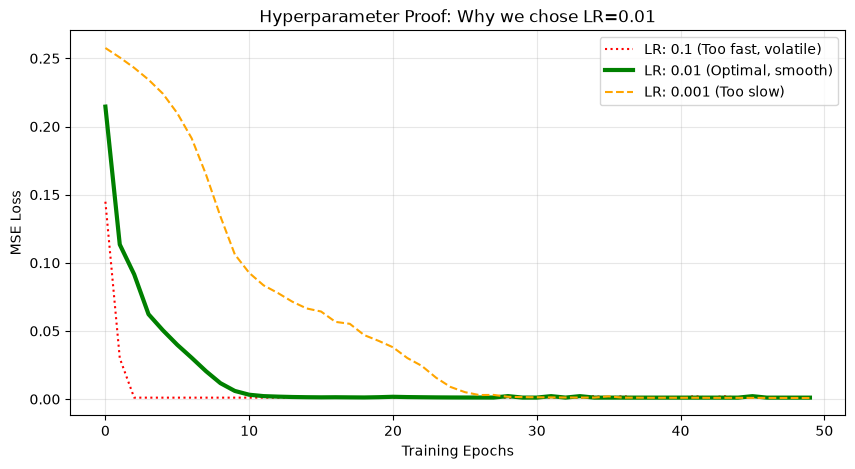

In [7]:
learning_rates = [0.1, 0.01, 0.001]
lr_loss_history = {lr: [] for lr in learning_rates}

print("🚀 Running Hyperparameter Grid Search (Learning Rates)...")

for lr in learning_rates:
    temp_model = ZeroTrustAutoencoder(input_dim)
    optimizer = optim.Adam(temp_model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    for epoch in range(50): # 50 epochs is enough to see the trend
        total_loss = 0
        for batch_features, _ in train_loader:
            optimizer.zero_grad()
            loss = criterion(temp_model(batch_features), batch_features)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        lr_loss_history[lr].append(total_loss / len(train_loader))

plt.figure(figsize=(10, 5))
plt.plot(lr_loss_history[0.1], label='LR: 0.1 (Too fast, volatile)', color='red', linestyle=':')
plt.plot(lr_loss_history[0.01], label='LR: 0.01 (Optimal, smooth)', color='green', linewidth=3)
plt.plot(lr_loss_history[0.001], label='LR: 0.001 (Too slow)', color='orange', linestyle='--')

plt.title('Hyperparameter Proof: Why we chose LR=0.01')
plt.xlabel('Training Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


🚀 Running Architecture Search (Latent Space Dimensions)...


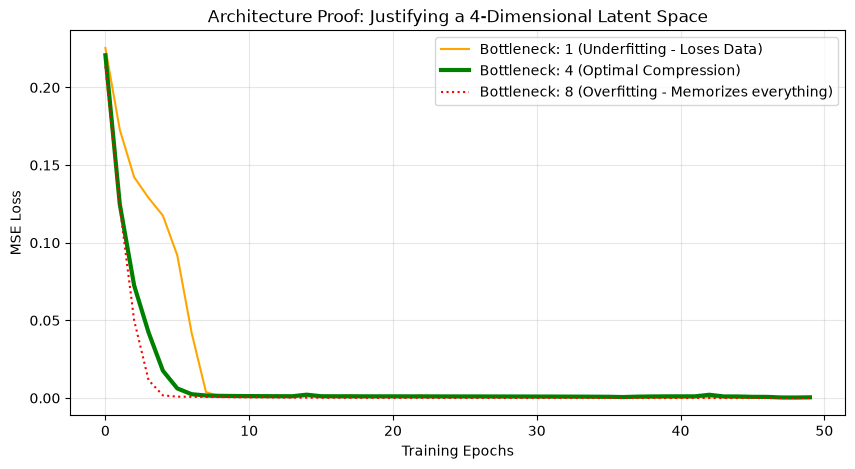

In [12]:
# Create custom autoencoders with different bottleneck sizes
class CustomAE(nn.Module):
    def __init__(self, input_dim, bottleneck_size):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 8), nn.ReLU(), nn.Linear(8, bottleneck_size))
        self.decoder = nn.Sequential(nn.Linear(bottleneck_size, 8), nn.ReLU(), nn.Linear(8, input_dim), nn.Sigmoid())
    def forward(self, x): return self.decoder(self.encoder(x))

bottlenecks = [1, 4, 8]
bottle_losses = {b: [] for b in bottlenecks}

print("🚀 Running Architecture Search (Latent Space Dimensions)...")

for b in bottlenecks:
    temp_model = CustomAE(input_dim, b)
    optimizer = optim.Adam(temp_model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    
    for epoch in range(50):
        total_loss = 0
        for batch_features, _ in train_loader:
            optimizer.zero_grad()
            loss = criterion(temp_model(batch_features), batch_features)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        bottle_losses[b].append(total_loss / len(train_loader))

plt.figure(figsize=(10, 5))
plt.plot(bottle_losses[1], label='Bottleneck: 1 (Underfitting - Loses Data)', color='orange')
plt.plot(bottle_losses[4], label='Bottleneck: 4 (Optimal Compression)', color='green', linewidth=3)
plt.plot(bottle_losses[8], label='Bottleneck: 8 (Overfitting - Memorizes everything)', color='red', linestyle=':')

plt.title('Architecture Proof: Justifying a 4-Dimensional Latent Space')
plt.xlabel('Training Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [13]:
import os
import sys
import pandas as pd

import config
from dataset import HubbleDataProcessor

try:
    from pyod.models.iforest import IForest
except ImportError:
    print("❌ Error: PyOD is not installed. Please run: pip install pyod scikit-learn")
    sys.exit(1)

def run_pyod_comparison():
    print("🌲 Initializing PyOD Baseline (Isolation Forest)...")

    if not os.path.exists(config.TRAIN_DATA_PATH) or not os.path.exists(config.TEST_DATA_PATH):
        print("❌ Error: Data files not found. Ensure hubble_training_data.json and hubble_test_data.json exist.")
        return

   
    print("📊 Loading Training Data...")
    train_processor = HubbleDataProcessor(config.TRAIN_DATA_PATH)
    train_processor.load_and_filter()
    train_processor.engineer_features()
    X_train = train_processor.get_dataframe().values

    # Load Test Data (Mixed benign and attacks)
    print("📊 Loading Test Data...")
    test_processor = HubbleDataProcessor(config.TEST_DATA_PATH)
    test_processor.load_and_filter()
    test_processor.engineer_features()
    X_test = test_processor.get_dataframe().values
    test_raw_events = test_processor.raw_data

    # Train PyOD Isolation Forest
    # 'contamination' is the expected percentage of anomalies in the training set.
    # We set it to 0.01 (1%) because our training set is almost purely benign.
    clf = IForest(contamination=0.01, random_state=42)
    
    print("\n⚙️  Training Isolation Forest on benign baseline...")
    clf.fit(X_train)

    # Predict on Test Data
    print("🚀 Running Inference on Test Data...")
    # predict() returns 0 for normal, 1 for anomaly
    y_test_pred = clf.predict(X_test) 
    # decision_function() returns the raw anomaly scores
    y_test_scores = clf.decision_function(X_test) 

    print("\n" + "="*80)
    print("🎯 PyOD Isolation Forest Results:")
    print("="*80)

    anomalies_caught = 0
    for i in range(len(X_test)):
        context = test_raw_events[i]
        flow_desc = f"[{context['src_app']}] -> {context['method']} {context['url']}"
        
        if y_test_pred[i] == 1:
            anomalies_caught += 1
            print(f"🚨 ANOMALY DETECTED! (Outlier Score: {y_test_scores[i]:.4f})")
            print(f"   Context: {flow_desc}\n")
            
    print("=" * 80)
    print(f"Total Flows Inspected: {len(X_test)}")
    print(f"Threats Neutralized by PyOD: {anomalies_caught}")

if __name__ == "__main__":
    run_pyod_comparison()

🌲 Initializing PyOD Baseline (Isolation Forest)...
📊 Loading Training Data...
🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_training_data.json...
✅ Filtered down to 100 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.
📊 Loading Test Data...
🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_attack_data.json...
✅ Filtered down to 26 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.

⚙️  Training Isolation Forest on benign baseline...
🚀 Running Inference on Test Data...

🎯 PyOD Isolation Forest Results:
🚨 ANOMALY DETECTED! (Outlier Score: 0.2907)
   Context: [retail-dashboard] -> GET http://customer-api:8000/health

🚨 ANOMALY DETECTED! (Outlier Score: 0.2907)
   Context: [retail-dashboard] -> GET http://customer-api:8000/customers/admin_dump

🚨 ANOMALY DETECTED! (Outlier Score: 0.2907)
   Context: [retail-dashboard] -> GET http://customer-api:8000/customers/admin_dump



In [16]:
import os
import sys
import pandas as pd

import config
from dataset import HubbleDataProcessor

try:
    from pyod.models.iforest import IForest
    from pyod.models.knn import KNN
    from pyod.models.ocsvm import OCSVM
except ImportError:
    print("❌ Error: PyOD is not installed. Please run: pip install pyod scikit-learn")
    sys.exit(1)

# PyOD's neural networks require TensorFlow/Keras. We handle it gracefully.
try:
    from pyod.models.auto_encoder import AutoEncoder
    HAS_TF = True
except ImportError:
    HAS_TF = False

def run_pyod_comparison():
    print("🌲 Initializing PyOD Multi-Model Comparison...")

    if not os.path.exists(config.TRAIN_DATA_PATH) or not os.path.exists(config.TEST_DATA_PATH):
        print("❌ Error: Data files not found. Ensure hubble_training_data.json and hubble_test_data.json exist.")
        return

    # 1. Load Training Data
    print("📊 Loading Training Data...")
    train_processor = HubbleDataProcessor(config.TRAIN_DATA_PATH)
    train_processor.load_and_filter()
    train_processor.engineer_features()
    X_train = train_processor.get_dataframe().values

    # 2. Load Test Data
    print("📊 Loading Test Data...")
    test_processor = HubbleDataProcessor(config.TEST_DATA_PATH)
    test_processor.load_and_filter()
    test_processor.engineer_features()
    X_test = test_processor.get_dataframe().values
    test_raw_events = test_processor.raw_data

    input_dim = X_train.shape[1]

    # 3. Define the Arsenal of Models
    # Contamination is set to 1% since our baseline is mostly pure
    classifiers = {
        "Isolation Forest (Tree-Based)": IForest(contamination=0.01, random_state=42),
        "K-Nearest Neighbors (Distance-Based)": KNN(contamination=0.01),
        "One-Class SVM (Margin-Based)": OCSVM(contamination=0.01)
    }

    if HAS_TF:
        # We mimic the exact architecture we built manually in PyTorch!
        classifiers["PyOD AutoEncoder (Neural Network)"] = AutoEncoder(
            hidden_neurons=[input_dim, 16, 8, 4, 8, 16, input_dim],
            epochs=50,
            contamination=0.01,
            verbose=0 # Keeps the console output clean
        )
    else:
        print("\n⚠️  Note: Skipping PyOD AutoEncoder. Install TensorFlow (`pip install tensorflow`) to test PyOD's neural networks.")

    print("\n" + "="*80)
    print("🎯 PyOD Multi-Model Comparison Results:")
    print("="*80)

    # 4. Train and Evaluate each model
    for name, clf in classifiers.items():
        print(f"\n⚙️  Testing: {name}")
        clf.fit(X_train)
        
        y_test_pred = clf.predict(X_test) 
        y_test_scores = clf.decision_function(X_test) 

        anomalies_caught = 0
        
        for i in range(len(X_test)):
            context = test_raw_events[i]
            flow_desc = f"[{context['src_app']}] -> {context['method']} {context['url']}"
            
            if y_test_pred[i] == 1:
                anomalies_caught += 1
                print(f"   🚨 BLOCKED ({y_test_scores[i]:.4f}): {flow_desc}")
                
        print(f"   ✅ Threats Neutralized by {name}: {anomalies_caught} / {len(X_test)} flows")

if __name__ == "__main__":
    run_pyod_comparison()

🌲 Initializing PyOD Multi-Model Comparison...
📊 Loading Training Data...
🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_training_data.json...
✅ Filtered down to 100 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.
📊 Loading Test Data...
🐝 Loading raw Hubble logs from /home/diaa/AuraNet/monolith_training/data/raw/hubble_attack_data.json...
✅ Filtered down to 26 pure, relevant network events.
🧠 Engineered Feature Matrix: 9 dimensions.

⚠️  Note: Skipping PyOD AutoEncoder. Install TensorFlow (`pip install tensorflow`) to test PyOD's neural networks.

🎯 PyOD Multi-Model Comparison Results:

⚙️  Testing: Isolation Forest (Tree-Based)
   🚨 BLOCKED (0.2907): [retail-dashboard] -> GET http://customer-api:8000/health
   🚨 BLOCKED (0.2907): [retail-dashboard] -> GET http://customer-api:8000/customers/admin_dump
   🚨 BLOCKED (0.2907): [retail-dashboard] -> GET http://customer-api:8000/customers/admin_dump
   🚨 BLOCKED (0.2907): [retail

In [19]:
import warnings
warnings.filterwarnings('ignore') # Suppress TF verbose logging in the notebook

try:
    from pyod.models.auto_encoder import AutoEncoder
    
    print("🌲 Initializing PyOD AutoEncoder (TensorFlow Backend)...")
    
    # We mimic the exact architecture we built manually in PyTorch!
    pyod_ae = AutoEncoder(
        hidden_neurons=[input_dim, 16, 8, 4, 8, 16, input_dim],
        epochs=50,
        contamination=0.05, # Expecting roughly 5% anomalies
        verbose=0
    )
    
    print("⚙️ Training PyOD model on benign baseline...")
    pyod_ae.fit(df_train.values)
    
    print("🔍 Predicting on mixed Test Data...")
    pyod_scores = pyod_ae.decision_function(df_test.values)
    
    pyod_normal_scores = []
    pyod_anomaly_scores = []

    # Separate scores using the same heuristic
    for i in range(len(df_test)):
        context = raw_events[i]
        if context['method'] in ['POST', 'DELETE'] or df_test.iloc[i]['is_valid_path'] == 0.0:
            pyod_anomaly_scores.append(pyod_scores[i])
        else:
            pyod_normal_scores.append(pyod_scores[i])

    plt.figure(figsize=(12, 6))
    plt.hist(pyod_normal_scores, bins=15, alpha=0.8, color='#10b981', label='Benign Traffic')
    plt.hist(pyod_anomaly_scores, bins=15, alpha=0.8, color='#ef4444', label='Malicious Traffic')

    # PyOD calculates an automatic threshold based on the 'contamination' parameter
    plt.axvline(x=pyod_ae.threshold_, color='#f59e0b', linestyle='--', linewidth=3, 
                label=f'PyOD Auto-Threshold ({pyod_ae.threshold_:.4f})')

    plt.title('PyOD AutoEncoder (TensorFlow) Anomaly Scores')
    plt.xlabel('Anomaly Score')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

except ImportError:
    print("❌ TensorFlow or PyOD not installed.")
    print("   Please run: pip install pyod tensorflow scikit-learn")


❌ TensorFlow or PyOD not installed.
   Please run: pip install pyod tensorflow scikit-learn
